# Investigating Factors Contributing to High Star Ratings on Yelp

- **Author**: Ervin Pangilinan
- COSC 526: Data Mining & Analytics Spring 2025


## Import Libraries for Pre-Processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Data Preprocessing

Once we load the raw data, we will need to extract the relevant features for our analysis.

In [2]:
business_df = pd.read_json('yelp_academic_dataset_business.json', lines=True)

# Drop unnecessary columns
business_df = business_df.drop(columns=['is_open', 'business_id'])
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,attributes,categories,hours
0,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
5,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
6,Famous Footwear,"8522 Eager Road, Dierbergs Brentwood Point",Brentwood,MO,63144,38.627695,-90.340465,2.5,13,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Sporting Goods, Fashion, Shoe Stores, Shopping...","{'Monday': '0:0-0:0', 'Tuesday': '10:0-18:0', ..."
7,Temple Beth-El,400 Pasadena Ave S,St. Petersburg,FL,33707,27.766590,-82.732983,3.5,5,None,"Synagogues, Religious Organizations","{'Monday': '9:0-17:0', 'Tuesday': '9:0-17:0', ..."
8,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."


In [3]:
business_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   name          150346 non-null  object 
 1   address       150346 non-null  object 
 2   city          150346 non-null  object 
 3   state         150346 non-null  object 
 4   postal_code   150346 non-null  object 
 5   latitude      150346 non-null  float64
 6   longitude     150346 non-null  float64
 7   stars         150346 non-null  float64
 8   review_count  150346 non-null  int64  
 9   attributes    136602 non-null  object 
 10  categories    150243 non-null  object 
 11  hours         127123 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 13.8+ MB


After loading the data, we see that we will need to filter the data to only include restaurants that are in the data. Next, we'll have to do additional preprocessing to clean the data and only include restaurants.

In [4]:
# Filter for businesses with the restaurant attribute
business_df = business_df[business_df['categories'].str.contains('Restaurant', na=False)]
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,attributes,categories,hours
3,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
12,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B...","{'Monday': '6:0-22:0', 'Tuesday': '6:0-22:0', ..."
14,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants","{'Monday': '10:0-18:0', 'Tuesday': '10:0-20:0'..."
15,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese","{'Tuesday': '13:30-22:0', 'Wednesday': '13:30-..."
19,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants","{'Monday': '11:30-20:30', 'Tuesday': '11:30-20..."
20,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"{'OutdoorSeating': 'False', 'Caters': 'True', ...","Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...","{'Monday': '8:0-18:0', 'Tuesday': '8:0-18:0', ..."


#### Dealing with Missing Values

Next, let's check for missing values in the data. We will need to drop any rows that have missing values in the features we are interested in. We will also need to convert the data types of some of the columns to make them easier to work with.

In [5]:
# Replace cells with only blank spaces in any column with NaN and check for missing data
business_df = business_df.applymap(lambda x: np.nan if isinstance(x, str) and not x.strip() else x)
missing_data = business_df[business_df.isnull().any(axis=1)]
missing_data.head(10)

/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/3715250282.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  business_df = business_df.applymap(lambda x: np.nan if isinstance(x, str) and not x.strip() else x)


,name,address,city,state,postal_code,latitude,longitude,stars,review_count,attributes,categories,hours
8,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
11,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
24,Super Dog,1160 Gallatin Pike S,Nashville,TN,37115,36.248570,-86.719986,4.0,6,"{'RestaurantsReservations': 'False', 'Restaura...","Hot Dogs, Restaurants",None
36,Cheeseburger In Paradise,116 N Pottstown Pike,Exton,PA,19341,40.029962,-75.630607,2.5,20,"{'NoiseLevel': 'u'average'', 'HasTV': 'True', ...","Restaurants, Burgers",None
62,Village Tap Room,838 Broad Ripple Ave,Indianapolis,IN,46220,39.869911,-86.143577,2.5,23,"{'Alcohol': 'u'none'', 'BestNights': '{'monday...","Gastropubs, Cocktail Bars, Beer Bar, Bars, Res...",None
64,Doc Magrogan's Oyster House - West Chester,117 E Gay St,West Chester,PA,19380,39.961542,-75.603604,3.0,114,"{'WiFi': 'u'no'', 'RestaurantsAttire': 'u'casu...","Seafood, Restaurants, Bars, Nightlife, Cocktai...",None
73,Sharky's Sports Bar & Grill,820 N Black Horse Pike,Williamstown,NJ,08094,39.696801,-74.999821,2.5,29,"{'Alcohol': 'u'full_bar'', 'RestaurantsGoodFor...","American (Traditional), Bars, Nightlife, Sport...",None
78,Gavi Italian Restaurant,"7401 N La Cholla Blvd, Ste 146",Tucson,AZ,85707,32.221667,-110.925833,3.5,9,"{'RestaurantsPriceRange2': '2', 'RestaurantsRe...","Italian, Restaurants",None
83,Super Sushi Kyo Hin,2501 Mt Holly Rd 245,Burlington,NJ,08016,40.041629,-74.825821,3.5,6,"{'RestaurantsReservations': 'True', 'Restauran...","Restaurants, Japanese, Sushi Bars, Asian Fusion",None
93,Impasto,NaN,Tampa,FL,33611,27.890814,-82.502346,5.0,5,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Italian, Food Trucks, Food","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."


In [6]:
missing_data_count = business_df.isnull().sum()
print(f"Missing data count:\n{missing_data_count}")

# Total number of rows with missing data
total_missing_data = missing_data.shape[0]
print(f"\nTotal number of rows with missing data: {total_missing_data}")

Missing data count:
name               0
address          443
city               0
state              0
postal_code       21
latitude           0
longitude          0
stars              0
review_count       0
attributes       566
categories         0
hours           7279
dtype: int64

Total number of rows with missing data: 7800


We see that there out of the 52286 samples in our dataset, 7800 of them have missing values. Further investigation is needed to see which features have missing values and how we can handle them.

In [7]:
# Calculate the percentage of missing values in each column
missing_percentage = business_df.isnull().mean()
missing_percentage

name            0.000000
address         0.008473
city            0.000000
state           0.000000
postal_code     0.000402
latitude        0.000000
longitude       0.000000
stars           0.000000
review_count    0.000000
attributes      0.010825
categories      0.000000
hours           0.139215
dtype: float64

##### Missing Attributes
Since samples with missing attributes only make up about 1% of this reduced dataset, we can drop them.

In [8]:
# Drop rows with missing attributes
business_df = business_df.dropna(subset=['attributes'])

# Check the number of rows after dropping missing values
print(f"Number of rows after dropping missing values: {business_df.shape[0]}")

Number of rows after dropping missing values: 51720


##### Missing Hours and Transforming the Feature

In this dataset, the hours are listed as a dictionary with the days of the week as keys and the hours of operation as values. We will need to convert this to a more usable format. We will transform this feature into hours open during the week and hours open on weekends. 

In [9]:
# Transform the hours column into 2 columns: number of hours open during weekdays and weekends
def transform_hours(hours):
    if not isinstance(hours, dict):
        return pd.Series([np.nan, np.nan])
    weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    weekend = ['Saturday', 'Sunday']
    weekday_hours = sum([len(v) for k, v in hours.items() if k in weekdays])
    weekend_hours = sum([len(v) for k, v in hours.items() if k in weekend])
    return pd.Series([weekday_hours, weekend_hours])

if 'hours' in business_df.columns:
    business_df[['weekday_hours', 'weekend_hours']] = business_df['hours'].apply(transform_hours)
    business_df = business_df.drop(columns=['hours'])

# Check the first few rows of the transformed DataFrame
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,attributes,categories,weekday_hours,weekend_hours
3,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...",40.0,16.0
5,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...",38.0,16.0
8,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",NaN,NaN
9,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",39.0,16.0
11,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks",45.0,17.0
12,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B...",40.0,16.0
14,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants",45.0,9.0
15,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese",40.0,20.0
19,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants",55.0,11.0
20,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"{'OutdoorSeating': 'False', 'Caters': 'True', ...","Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",40.0,17.0


We don't want to drop the rows with missing values in the hours column because it made up 14% of our dataset. Instead, we will use the median value to fill in the missing values since samples that had missing hours values will in turn have missing values in the hours open during the week and hours open on weekends.

In [10]:
# Fill in missing values in the weekday_hours and weekend_hours columns with with the median value of the column
weekday_hours_mode = business_df['weekday_hours'].median()
weekend_hours_mode = business_df['weekend_hours'].median()
business_df['weekday_hours'] = business_df['weekday_hours'].fillna(weekday_hours_mode)
business_df['weekend_hours'] = business_df['weekend_hours'].fillna(weekend_hours_mode)

# Check the first few rows of the DataFrame after filling missing values
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,attributes,categories,weekday_hours,weekend_hours
3,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...",40.0,16.0
5,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...",38.0,16.0
8,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",43.0,18.0
9,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",39.0,16.0
11,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks",45.0,17.0
12,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"{'RestaurantsReservations': 'False', 'Restaura...","American (Traditional), Restaurants, Diners, B...",40.0,16.0
14,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"{'OutdoorSeating': 'False', 'RestaurantsGoodFo...","Food, Delis, Italian, Bakeries, Restaurants",45.0,9.0
15,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"{'RestaurantsReservations': 'True', 'Restauran...","Sushi Bars, Restaurants, Japanese",40.0,20.0
19,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"{'NoiseLevel': 'u'quiet'', 'GoodForMeal': '{'d...","Korean, Restaurants",55.0,11.0
20,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"{'OutdoorSeating': 'False', 'Caters': 'True', ...","Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",40.0,17.0


#### Flattening Raw Data for Features

In [11]:
# Flatten the DataFrame completely
def flatten_column(df, col):
    # Expand the first-level attributes dictionary
    df = df.copy()
    attributes_expanded = pd.json_normalize(df[col])

    # Merge carefully by resetting indices
    df = df.reset_index(drop=True)
    attributes_expanded = attributes_expanded.reset_index(drop=True)
    df = pd.concat([df, attributes_expanded], axis=1)
    
    # Drop the original attributes column
    df = df.drop(columns=[col])

    return df

business_df = flatten_column(business_df, 'attributes')
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,categories,...,BestNights,BYOB,Corkage,BYOBCorkage,RestaurantsCounterService,Open24Hours,AgesAllowed,DietaryRestrictions,HairSpecializesIn,AcceptsInsurance
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"American (Traditional), Restaurants, Diners, B...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"Food, Delis, Italian, Bakeries, Restaurants",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"Sushi Bars, Restaurants, Japanese",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"Korean, Restaurants",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's check for missing data again.

In [12]:
# Check percentage of missing values in the flattened DataFrame
missing_percentage = business_df.isnull().mean()
print(f"Missing percentage in flattened DataFrame:\n{missing_percentage}")

Missing percentage in flattened DataFrame:
name                          0.000000
address                       0.007966
city                          0.000000
state                         0.000000
postal_code                   0.000387
latitude                      0.000000
longitude                     0.000000
stars                         0.000000
review_count                  0.000000
categories                    0.000000
weekday_hours                 0.000000
weekend_hours                 0.000000
RestaurantsDelivery           0.078538
OutdoorSeating                0.156226
BusinessAcceptsCreditCards    0.118852
BusinessParking               0.117807
BikeParking                   0.313708
RestaurantsPriceRange2        0.139346
RestaurantsTakeOut            0.058063
ByAppointmentOnly             0.935247
WiFi                          0.270128
Alcohol                       0.226991
Caters                        0.331535
RestaurantsAttire             0.246094
RestaurantsReservatio

We'll drop the columns where the percentage of missing values is greater than 50%.

In [13]:
# Drop columns with more than 50% missing values
missing_percentage = business_df.isnull().mean()
columns_to_drop = missing_percentage[missing_percentage >= 0.5].index
business_df = business_df.drop(columns=columns_to_drop)

# Check the number of rows and columns after dropping columns
print(f"Number of rows and columns after dropping columns: {business_df.shape}")

missing_percentage = business_df.isnull().mean()
print(f"Missing percentage in flattened DataFrame:\n{missing_percentage}")

business_df.head(10)

Number of rows and columns after dropping columns: (51720, 30)
Missing percentage in flattened DataFrame:
name                          0.000000
address                       0.007966
city                          0.000000
state                         0.000000
postal_code                   0.000387
latitude                      0.000000
longitude                     0.000000
stars                         0.000000
review_count                  0.000000
categories                    0.000000
weekday_hours                 0.000000
weekend_hours                 0.000000
RestaurantsDelivery           0.078538
OutdoorSeating                0.156226
BusinessAcceptsCreditCards    0.118852
BusinessParking               0.117807
BikeParking                   0.313708
RestaurantsPriceRange2        0.139346
RestaurantsTakeOut            0.058063
WiFi                          0.270128
Alcohol                       0.226991
Caters                        0.331535
RestaurantsAttire             0.2460

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,categories,...,Alcohol,Caters,RestaurantsAttire,RestaurantsReservations,Ambience,GoodForKids,RestaurantsGoodForGroups,HasTV,NoiseLevel,GoodForMeal
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,u'none',True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",...,u'none',False,u'casual',False,None,True,True,True,NaN,NaN
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",...,u'full_bar',True,u'casual',False,"{'romantic': False, 'intimate': False, 'touris...",True,True,True,u'average',NaN
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",...,u'none',False,'casual',False,NaN,True,False,True,NaN,NaN
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",...,'none',NaN,NaN,False,"{'touristy': False, 'hipster': False, 'romanti...",NaN,NaN,NaN,NaN,"{'dessert': False, 'latenight': False, 'lunch'..."
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"American (Traditional), Restaurants, Diners, B...",...,'none',NaN,'casual',False,"{'touristy': None, 'hipster': None, 'romantic'...",True,True,True,NaN,"{'dessert': False, 'latenight': False, 'lunch'..."
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"Food, Delis, Italian, Bakeries, Restaurants",...,u'none',True,u'casual',False,"{'romantic': False, 'intimate': False, 'touris...",True,False,True,u'average',"{'dessert': False, 'latenight': False, 'lunch'..."
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"Sushi Bars, Restaurants, Japanese",...,'full_bar',NaN,'casual',True,"{'touristy': False, 'hipster': False, 'romanti...",False,True,False,u'average',"{'dessert': True, 'latenight': None, 'lunch': ..."
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"Korean, Restaurants",...,u'none',True,u'casual',False,"{'touristy': False, 'hipster': False, 'romanti...",True,False,True,u'quiet',"{'dessert': False, 'latenight': False, 'lunch'..."
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",...,u'beer_and_wine',True,u'casual',False,"{'romantic': False, 'intimate': False, 'classy...",False,True,False,u'average',NaN


#### Cleaning Usable Features
We will also need to convert the data types of some of the columns to make them easier to work with.

In [14]:
bool_columns = [
    'RestaurantsDelivery', 'OutdoorSeating', 'BusinessAcceptsCreditCards',
    'RestaurantsReservations', 'Caters', 'BikeParking', 'RestaurantsTakeOut',
    'RestaurantsGoodForGroups', 'GoodForKids', 'HasTV'
]

for col in bool_columns:
    # Perform one-hot encoding for boolean columns
    business_df[col] = business_df[col].replace({None: False})
    business_df[col] = business_df[col].astype(bool)
    business_df[col] = business_df[col].replace({True: 1, False: 0})

missing_percentage = business_df.isnull().mean()
print(f"Missing percentage in flattened DataFrame:\n{missing_percentage}")

business_df.head(10)

/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/2431074477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  business_df[col] = business_df[col].replace({True: 1, False: 0})
/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/2431074477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  business_df[col] = business_df[col].replace({True: 1, False: 0})
/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/2431074477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and w

Missing percentage in flattened DataFrame:
name                          0.000000
address                       0.007966
city                          0.000000
state                         0.000000
postal_code                   0.000387
latitude                      0.000000
longitude                     0.000000
stars                         0.000000
review_count                  0.000000
categories                    0.000000
weekday_hours                 0.000000
weekend_hours                 0.000000
RestaurantsDelivery           0.000000
OutdoorSeating                0.000000
BusinessAcceptsCreditCards    0.000000
BusinessParking               0.117807
BikeParking                   0.000000
RestaurantsPriceRange2        0.139346
RestaurantsTakeOut            0.000000
WiFi                          0.270128
Alcohol                       0.226991
Caters                        0.000000
RestaurantsAttire             0.246094
RestaurantsReservations       0.000000
Ambience             

/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/2431074477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  business_df[col] = business_df[col].replace({True: 1, False: 0})
/var/folders/qd/cq8k89k14gs26x42sg8fmrxc0000gn/T/ipykernel_1319/2431074477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  business_df[col] = business_df[col].replace({True: 1, False: 0})


,name,address,city,state,postal_code,latitude,longitude,stars,review_count,categories,...,Alcohol,Caters,RestaurantsAttire,RestaurantsReservations,Ambience,GoodForKids,RestaurantsGoodForGroups,HasTV,NoiseLevel,GoodForMeal
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,u'none',1,NaN,0,NaN,0,0,0,NaN,NaN
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",...,u'none',1,u'casual',1,None,1,1,1,NaN,NaN
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",...,u'full_bar',1,u'casual',1,"{'romantic': False, 'intimate': False, 'touris...",1,1,1,u'average',NaN
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",...,u'none',1,'casual',1,NaN,1,1,1,NaN,NaN
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",...,'none',0,NaN,1,"{'touristy': False, 'hipster': False, 'romanti...",0,0,0,NaN,"{'dessert': False, 'latenight': False, 'lunch'..."
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"American (Traditional), Restaurants, Diners, B...",...,'none',0,'casual',1,"{'touristy': None, 'hipster': None, 'romantic'...",1,1,1,NaN,"{'dessert': False, 'latenight': False, 'lunch'..."
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"Food, Delis, Italian, Bakeries, Restaurants",...,u'none',1,u'casual',1,"{'romantic': False, 'intimate': False, 'touris...",1,1,1,u'average',"{'dessert': False, 'latenight': False, 'lunch'..."
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"Sushi Bars, Restaurants, Japanese",...,'full_bar',0,'casual',1,"{'touristy': False, 'hipster': False, 'romanti...",1,1,1,u'average',"{'dessert': True, 'latenight': None, 'lunch': ..."
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"Korean, Restaurants",...,u'none',1,u'casual',1,"{'touristy': False, 'hipster': False, 'romanti...",1,1,1,u'quiet',"{'dessert': False, 'latenight': False, 'lunch'..."
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",...,u'beer_and_wine',1,u'casual',1,"{'romantic': False, 'intimate': False, 'classy...",1,1,1,u'average',NaN


In [15]:
# Clean the 'RestaurantsPriceRange2' column
business_df['RestaurantsPriceRange2'] = pd.to_numeric(business_df['RestaurantsPriceRange2'], errors='coerce')
business_df['RestaurantsPriceRange2'] = business_df['RestaurantsPriceRange2'].fillna(business_df['RestaurantsPriceRange2'].mode()[0])

# Drop BusinessParking and GoodForMeal columns
business_df = business_df.drop(columns=['BusinessParking', 'GoodForMeal', 'Ambience'])
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,categories,...,RestaurantsTakeOut,WiFi,Alcohol,Caters,RestaurantsAttire,RestaurantsReservations,GoodForKids,RestaurantsGoodForGroups,HasTV,NoiseLevel
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,1,u'free',u'none',1,NaN,0,0,0,0,NaN
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",...,1,u'no',u'none',1,u'casual',1,1,1,1,NaN
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",...,1,u'free',u'full_bar',1,u'casual',1,1,1,1,u'average'
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",...,1,u'no',u'none',1,'casual',1,1,1,1,NaN
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",...,0,NaN,'none',0,NaN,1,0,0,0,NaN
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"American (Traditional), Restaurants, Diners, B...",...,1,u'no','none',0,'casual',1,1,1,1,NaN
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"Food, Delis, Italian, Bakeries, Restaurants",...,1,u'no',u'none',1,u'casual',1,1,1,1,u'average'
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"Sushi Bars, Restaurants, Japanese",...,1,'free','full_bar',0,'casual',1,1,1,1,u'average'
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"Korean, Restaurants",...,1,u'no',u'none',1,u'casual',1,1,1,1,u'quiet'
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",...,1,u'free',u'beer_and_wine',1,u'casual',1,1,1,1,u'average'


### Dealing with Missing Values from Remaining Features
There are still some missing values in the remaining features. We will need to fill in the missing values for the remaining features.

In [16]:
# Check percentage of missing values
missing_percentage = business_df.isnull().mean()

# Print the column names with missing values percentage greater than 1%
missing_columns = missing_percentage[missing_percentage >= 0.01].index
missing_percentage = business_df[missing_columns].isnull().mean()

print(f"Features with 1% or more for missing data:\n{missing_percentage}")

Features with 1% or more for missing data:
WiFi                 0.270128
Alcohol              0.226991
RestaurantsAttire    0.246094
NoiseLevel           0.326276
dtype: float64


Since these features are categorical, we will need to fill in the missing values with the mode of the column. We will also need to convert the data types of some of the columns to make them easier to work with.

In [17]:
columns_to_fill = ['WiFi', 'Alcohol', 'RestaurantsAttire', 'NoiseLevel']

# Fill missing values with the mode of the column
for col in columns_to_fill:
    business_df[col] = business_df[col].fillna(business_df[col].mode()[0])
    
# Perform one-hot encoding for categorical columns
business_df = pd.get_dummies(business_df, columns=columns_to_fill, drop_first=True)

# Check if column is boolean and change to 0/1 if necessary
for col in business_df.columns:
    if business_df[col].dtype == 'bool':
        business_df[col] = business_df[col].astype(int)
  
# Check the first few rows of the DataFrame after filling missing values
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,categories,...,RestaurantsAttire_u'dressy',RestaurantsAttire_u'formal',NoiseLevel_'loud',NoiseLevel_'quiet',NoiseLevel_'very_loud',NoiseLevel_None,NoiseLevel_u'average',NoiseLevel_u'loud',NoiseLevel_u'quiet',NoiseLevel_u'very_loud'
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",...,0,0,0,0,0,0,1,0,0,0
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",...,0,0,0,0,0,0,1,0,0,0
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,"Pubs, Restaurants, Italian, Bars, American (Tr...",...,0,0,0,0,0,0,1,0,0,0
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",...,0,0,0,0,0,0,1,0,0,0
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",...,0,0,0,0,0,0,1,0,0,0
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,"American (Traditional), Restaurants, Diners, B...",...,0,0,0,0,0,0,1,0,0,0
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,"Food, Delis, Italian, Bakeries, Restaurants",...,0,0,0,0,0,0,1,0,0,0
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,"Sushi Bars, Restaurants, Japanese",...,0,0,0,0,0,0,1,0,0,0
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,"Korean, Restaurants",...,0,0,0,0,0,0,0,0,1,0
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,"Coffee & Tea, Food, Cafes, Bars, Wine Bars, Re...",...,0,0,0,0,0,0,1,0,0,0


### Extracting Features from the Categories Column
We will need to extract the features from the categories column. We will need to convert the categories into a one-hot encoded format so that we can use them in our analysis. We will also need to drop the original categories column.

See the following for more information on categories provided by Yelp: https://blog.yelp.com/businesses/yelp_category_list/

In [18]:
business_df['categories_list'] = business_df['categories'].fillna('').apply(lambda x: [i.strip() for i in x.split(',')])

# Drop the original categories column
business_df = business_df.drop(columns=['categories'])
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,weekday_hours,...,RestaurantsAttire_u'formal',NoiseLevel_'loud',NoiseLevel_'quiet',NoiseLevel_'very_loud',NoiseLevel_None,NoiseLevel_u'average',NoiseLevel_u'loud',NoiseLevel_u'quiet',NoiseLevel_u'very_loud',categories_list
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,40.0,...,0,0,0,0,0,1,0,0,0,"[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,38.0,...,0,0,0,0,0,1,0,0,0,"[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,43.0,...,0,0,0,0,0,1,0,0,0,"[Pubs, Restaurants, Italian, Bars, American (T..."
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,39.0,...,0,0,0,0,0,1,0,0,0,"[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,45.0,...,0,0,0,0,0,1,0,0,0,"[Vietnamese, Food, Restaurants, Food Trucks]"
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,40.0,...,0,0,0,0,0,1,0,0,0,"[American (Traditional), Restaurants, Diners, ..."
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,45.0,...,0,0,0,0,0,1,0,0,0,"[Food, Delis, Italian, Bakeries, Restaurants]"
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,40.0,...,0,0,0,0,0,1,0,0,0,"[Sushi Bars, Restaurants, Japanese]"
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,55.0,...,0,0,0,0,0,0,0,1,0,"[Korean, Restaurants]"
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,40.0,...,0,0,0,0,0,1,0,0,0,"[Coffee & Tea, Food, Cafes, Bars, Wine Bars, R..."


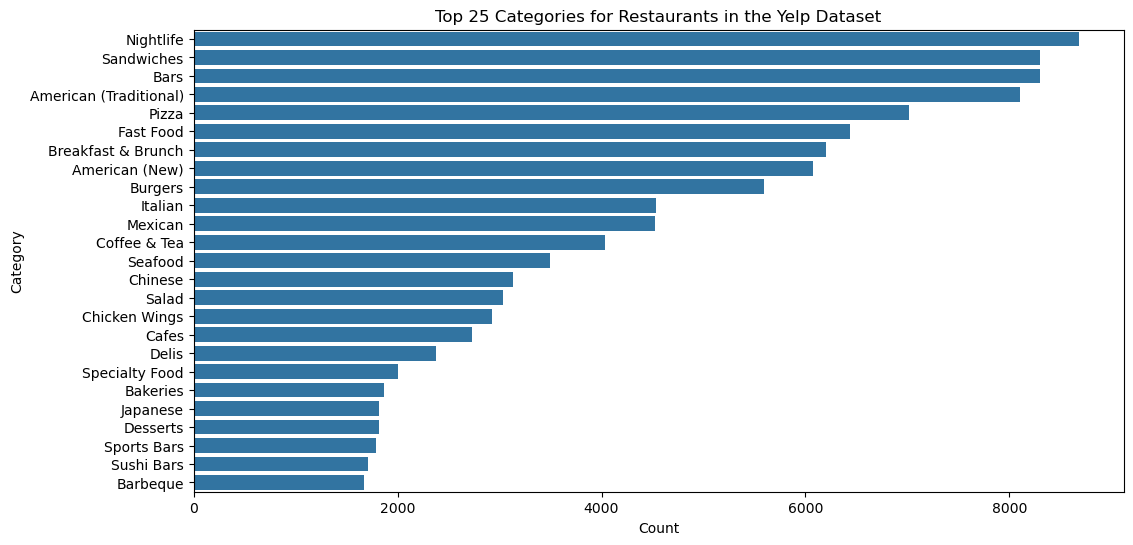

In [19]:
# Finding the most common categories
categories = business_df['categories_list'].explode()
categories = categories.str.strip()
categories = categories[categories != '']
categories = categories.value_counts()
categories = categories[categories > 100]
categories = categories.reset_index()
categories.columns = ['category', 'count']
categories = categories.sort_values(by='count', ascending=False)

# Remove the 'Restaurants' category and 'Food' category
categories = categories[~categories['category'].isin(['Restaurants', 'Food', 'Event Planning & Services', 'Caterers'])]

# Remove the 'Restaurants' and 'Food' categories from the DataFrame
business_df['categories_list'] = business_df['categories_list'].apply(lambda x: [i for i in x if i not in ['Restaurants', 'Food', 'Event Planning & Services', 'Caterers']])

# Plot the top 25 categories
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='category', data=categories.head(25))
plt.title('Top 25 Categories for Restaurants in the Yelp Dataset')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

Now that we know what the most common categories are, we can perform one-hot encoding on the categories column.

In [20]:
# One-hot encoding for the top 25 categories
top_25_categories = categories['category'].head(25).tolist()
for category in top_25_categories:
    business_df[category] = business_df['categories_list'].apply(lambda x: 1 if category in x else 0)
    
# Drop the categories_list column
business_df = business_df.drop(columns=['categories_list'])
business_df.head(10)

,name,address,city,state,postal_code,latitude,longitude,stars,review_count,weekday_hours,...,Chicken Wings,Cafes,Delis,Specialty Food,Bakeries,Japanese,Desserts,Sports Bars,Sushi Bars,Barbeque
0,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,40.0,...,0,0,0,0,1,0,0,0,0,0
1,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,38.0,...,0,0,0,0,0,0,0,0,0,0
2,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,43.0,...,0,0,0,0,0,0,0,0,0,0
3,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,39.0,...,0,0,0,0,0,0,0,0,0,0
4,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,45.0,...,0,0,0,0,0,0,0,0,0,0
5,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,40.0,...,0,0,0,0,0,0,0,0,0,0
6,Zio's Italian Market,2575 E Bay Dr,Largo,FL,33771,27.916116,-82.760461,4.5,100,45.0,...,0,0,1,0,1,0,0,0,0,0
7,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,245,40.0,...,0,0,0,0,0,1,0,0,1,0
8,BAP,1224 South St,Philadelphia,PA,19147,39.943223,-75.162568,4.5,205,55.0,...,0,0,0,0,0,0,0,0,0,0
9,Roast Coffeehouse and Wine Bar,10359 104 Street NW,Edmonton,AB,T5J 1B9,53.546045,-113.499169,4.0,40,40.0,...,0,1,0,0,0,0,0,0,0,0


We'll be using regression and clustering later on, so we will modify this DataFrame to be more usable for those tasks. For regression, we will remove longitude and latitude from the DataFrame. However, we will keep them for clustering. We will also remove
unnecesary columns such as the name and address of the restaurant.

In [21]:
columns_to_drop = ['name', 'address', 'city', 'state', 'postal_code']

# Extract the above columns to a new DataFrame
raw_data = business_df.copy()
raw_data.to_csv('raw_data.csv', index=False)
business_info_df = business_df[columns_to_drop].copy()

# Drop the columns from the original DataFrame
business_df = business_df.drop(columns=columns_to_drop)

# Making seperate datasets for regression and clustering
business_clustering_df = business_df.copy()
business_regression_df = business_df.copy().drop(columns=['longitude', 'latitude'])

# Export the DataFrames to CSV files
business_clustering_df.to_csv('business_clustering_df.csv', index=False)
business_regression_df.to_csv('business_regression_df.csv', index=False)
business_info_df.to_csv('business_info_df.csv', index=False)


## Data Exploration

First, we need to see the locations of the different restaurants in the dataset.



### Data Overview and Check for Outliers

In [22]:
business_df = pd.read_csv('raw_data.csv')
business_df.describe()

,latitude,longitude,stars,review_count,weekday_hours,weekend_hours,RestaurantsDelivery,OutdoorSeating,BusinessAcceptsCreditCards,BikeParking,...,Chicken Wings,Cafes,Delis,Specialty Food,Bakeries,Japanese,Desserts,Sports Bars,Sushi Bars,Barbeque
count,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,...,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000,51720.000000
mean,36.994005,-87.822775,3.513331,88.099652,41.710093,16.127630,0.921462,0.843774,0.881148,0.686292,...,0.056671,0.052842,0.045940,0.038689,0.036195,0.035170,0.035151,0.034667,0.032985,0.032405
std,5.997331,13.800527,0.827028,189.763094,6.182128,4.016533,0.269019,0.363073,0.323617,0.464004,...,0.231214,0.223721,0.209356,0.192855,0.186777,0.184211,0.184163,0.182938,0.178600,0.177076
min,27.564457,-120.083748,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.219257,-90.231650,3.000000,14.000000,40.000000,16.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.485038,-86.031566,3.500000,34.000000,43.000000,18.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,39.958341,-75.336925,4.000000,90.000000,45.000000,18.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,53.679197,-74.664459,5.000000,7568.000000,55.000000,22.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


We see one outlier, which is that a restaurant has 7568 reviews.

In [23]:
# Find the restaurant that has 7568 reviews using business_info_df
restaurant_with_7568_reviews = raw_data[raw_data['review_count'] == 7568]
restaurant_with_7568_reviews[['name', 'address', 'city', 'state', 'review_count', 'stars']]

,name,address,city,state,review_count,stars
39097,Acme Oyster House,724 Iberville St,New Orleans,LA,7568,4.0


Further inspection shows that this restaurant has been around since 1910. It's useful real-world data worth keeping even though it is an outlier. We will keep this restaurant in the dataset.

### Visualizing the Locations of Restaurants

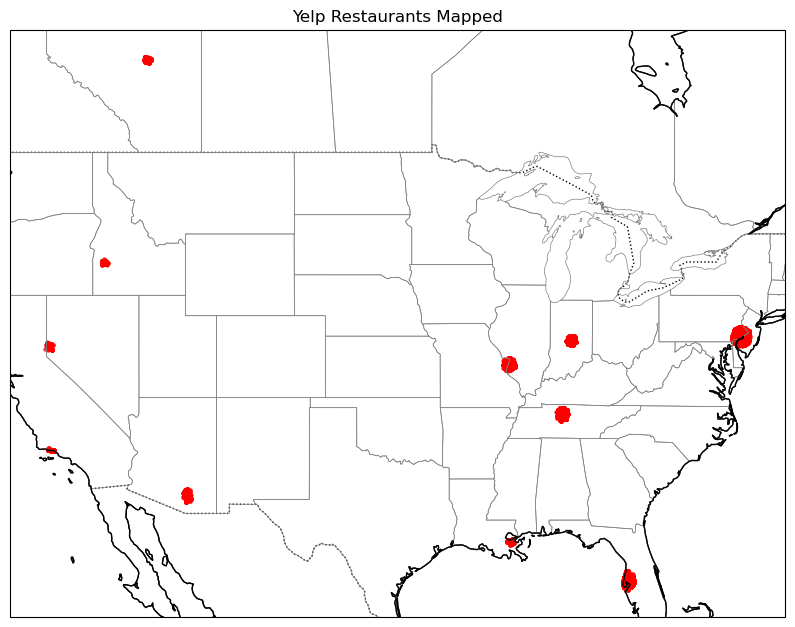

In [24]:
# Create a 'geometry' column
business_df['geometry'] = business_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)

# Convert regular DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(business_df, geometry='geometry')

# Set the coordinate reference system (CRS) - EPSG:4326 is WGS84 standard (lat/lon)
gdf.set_crs(epsg=4326, inplace=True)

# Setup plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot Yelp points
gdf.plot(ax=ax, markersize=5, alpha=0.7, color='red')

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', linewidth=1)
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', linewidth=0.5)        
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)                                      
ax.set_title('Yelp Restaurants Mapped')
plt.show()

### Exploring the Distribution of Star Ratings

We would like to see the distribution of star ratings in the dataset to see if the dataset is unbalanced.

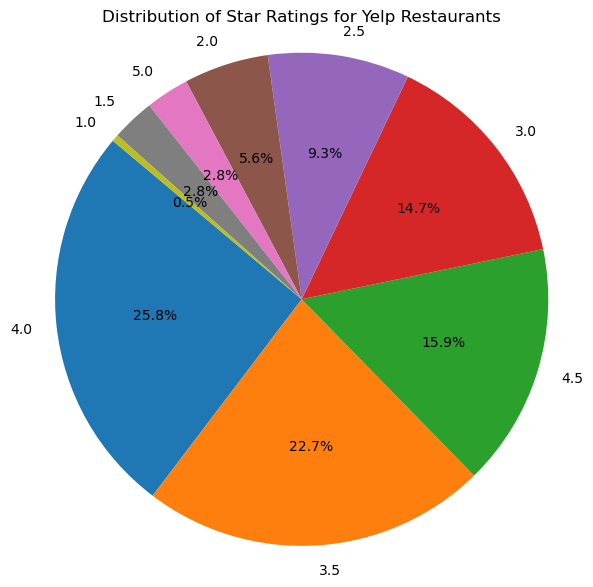

In [25]:
# Plot the distribution of star ratings as a pie chart
star_distribution = business_df['stars'].value_counts(normalize=True)
plt.figure(figsize=(7, 7))
plt.pie(star_distribution, labels=star_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Star Ratings for Yelp Restaurants')
plt.axis('equal')
plt.show()

We see that the distribution is heavily skewed. Almost half of the restaurants in the dataset have a star rating of either 3.5 or 4.0. This could pose a problem for our analysis since we will be using regression later on.

### Correlation of Features to Star Ratings

Our regression model will be used to predict the star ratings based on the features we have. We will need to see how the features are correlated with the star ratings. We will also need to see how the features are correlated with each other.

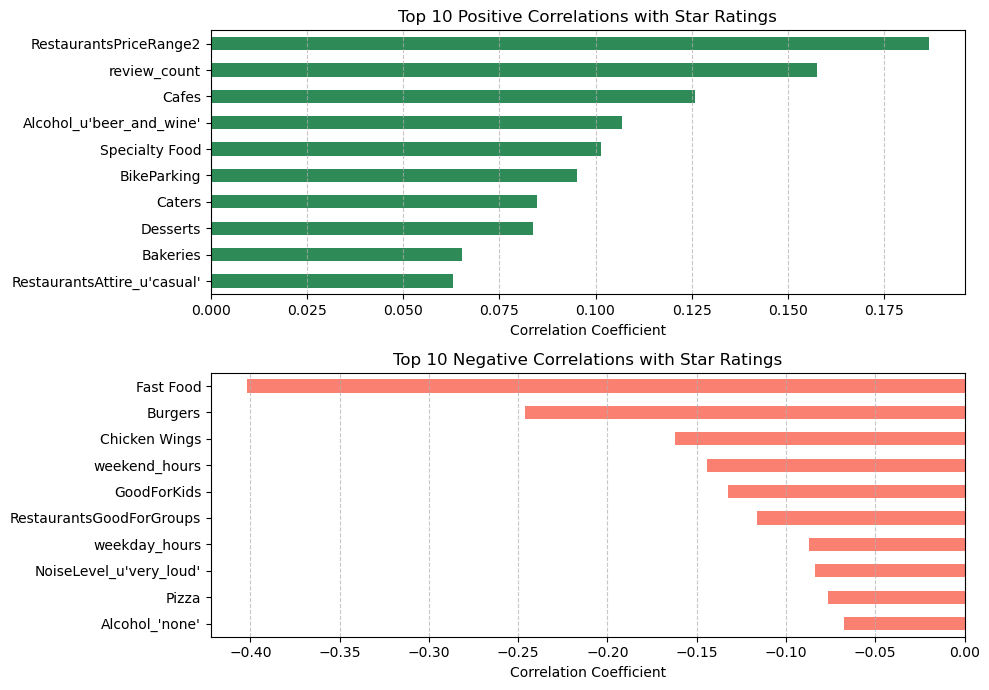

In [26]:
# Select numeric columns
numerical_cols = business_df.select_dtypes(include=['number']).columns

# Correlation matrix
corr_matrix = business_df[numerical_cols].corr()

# Drop 'stars' itself (perfect correlation)
stars_corr = corr_matrix['stars'].sort_values(ascending=False)
stars_corr = stars_corr.drop('stars')

# Split into positive and negative parts
positive_corr = stars_corr[stars_corr > 0]
negative_corr = stars_corr[stars_corr < 0]
top_positive_corr = stars_corr[stars_corr > 0].sort_values(ascending=False).head(10)
top_negative_corr = stars_corr[stars_corr < 0].sort_values().head(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Plot positive correlations
top_positive_corr.sort_values().plot(kind='barh', color='seagreen', ax=axes[0])
axes[0].set_title('Top 10 Positive Correlations with Star Ratings')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Plot negative correlations
top_negative_corr.sort_values(ascending=False).plot(kind='barh', color='salmon', ax=axes[1])
axes[1].set_title('Top 10 Negative Correlations with Star Ratings')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

From this plot, we can see that the star ratings are positively correlated with:

- restaurant price range
- review counts
- if the restaurant is a cafe

Even though these three features were the most positively correlated, the positive correlation is weak, compared to the top features for negative correlations.

We can also see that the star ratings are negatively correlated with:
- if the restaurant serves fast food
- if the restaurant serves burgers
- if the restaurant serves chicken wings

Specific food categories were surprising to see. Upon first glance, this could be due to the fact that these food categories are more likely to be fast food restaurants. However, seeing the fast food category as the most negatively correlated is realistic. In general, the food quality would be lower than traditional restaurants. Additionally, reviewers may tend to rate these chains harshly such as when an order is wrong or takes too long at the drive-thru. 

## Regression Analysis

For our regression analysis, we will be using tree-based models because of the one-hot encoding that was implemented during pre-processing. We will be using the following models:
- Random Forest
- Gradient Boosting
- XGBoost

### Importing Libraries for ML Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV

In [126]:
def evaluate(y_true, y_pred):
    print(f'MSE:  {mean_squared_error(y_true, y_pred):.4f}')
    print(f'RMSE: {root_mean_squared_error(y_true, y_pred):.4f}')
    print(f'MAE:  {mean_absolute_error(y_true, y_pred):.4f}')
    print(f'R^2:  {r2_score(y_true, y_pred):.4f}')

### Splitting the Dataset

In [ ]:
business_regression_df = pd.read_csv('business_regression_df.csv')

# Split the data into training and testing sets
X = business_regression_df.drop(columns=['stars'])
y = business_regression_df['stars']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Check the distribution of the target variable in the training set
print(f"Training set target variable distribution:\n{y_train.value_counts(normalize=True)}")

# Check the distribution of the target variable in the testing set
print(f"Testing set target variable distribution:\n{y_test.value_counts(normalize=True)}")

Training set size: 36204
Testing set size: 15516
Training set target variable distribution:
stars
4.0    0.256077
3.5    0.227627
4.5    0.160286
3.0    0.147083
2.5    0.091896
2.0    0.055740
1.5    0.028975
5.0    0.027732
1.0    0.004585
Name: proportion, dtype: float64
Testing set target variable distribution:
stars
4.0    0.261794
3.5    0.223962
4.5    0.157321
3.0    0.145334
2.5    0.095063
2.0    0.055298
5.0    0.029969
1.5    0.026682
1.0    0.004576
Name: proportion, dtype: float64


### Random Forest Regressor

We'll first use GridSearch to figure out the optimal hyperparameters to use for our Random Forest Regressor.

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 500],          
    'max_depth': [10, 20, 30, None],            
    'min_samples_split': [2, 5, 10],            
    'min_samples_leaf': [1, 2, 5, 10],         
    'max_features': ['sqrt', 'log2', 0.7, None] 
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch results tell us that the optimal configuration would have:

In [ ]:
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate the model
print("Random Forest Regressor Scores")
evaluate(y_test, y_pred_rf)

# Feature importance
importances = rf.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances with Random Forest Regressor")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylabel("Relative Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

### Histogram-based Gradient Boosting Regressor

In [ ]:
hgb_model = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'l2_regularization': [0, 0.1, 1.0],
    'max_leaf_nodes': [31, 50, 100]
}

grid_search_hgb = GridSearchCV(
    estimator=hgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_hgb.fit(X_train, y_train)

print("Best Parameters:", grid_search_hgb.best_params_)
print("Best Score (MSE):", -grid_search_hgb.best_score_)

We see that the optimal hyperparameter values are:
- l2 regularization: 1.0
- learning rate: 0.05
- max depth: 7
- max iterations: 300
- max leaf nodes: 50

In [ ]:
# Fit the Histogram-based Gradient Boosting Regressor with the best parameters
hgb_model = HistGradientBoostingRegressor(
    l2_regularization=1.0,
    learning_rate=0.05,
    max_depth=7,
    max_iter=300,
    max_leaf_nodes=50
)

hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

# Evaluate the model
print("Histogram-based Gradient Boosting Regressor Scores")
evaluate(y_test, y_pred_hgb)

result = permutation_importance(hgb_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importances = result.importances_mean
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances with Histogram-based Gradient Boosting Regressor")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.ylim(0, None)
plt.ylabel("Relative Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()